In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf

from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, ARIMA, AutoARIMA, AutoETS, AutoTheta

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# 1. Загрузка очищенных на прошлом этапе данных
df = pd.read_csv('../data/traffic_clean.csv')
df['ds'] = pd.to_datetime(df['ds'])
print(f"Загружено записей: {len(df)}")
df.head()

Загружено записей: 43776


,unique_id,ds,y
0,1,2015-11-01 00:00:00,15.0
1,1,2015-11-01 01:00:00,13.0
2,1,2015-11-01 02:00:00,10.0
3,1,2015-11-01 03:00:00,7.0
4,1,2015-11-01 04:00:00,9.0


In [2]:
# Задаем список моделей
models_pool = [
    SeasonalNaive(season_length=168), 
    ARIMA(order=(1, 1, 1), seasonal_order=(0, 1, 1), season_length=24),
    AutoARIMA(season_length=24, approximation=True), 
    AutoETS(season_length=24),
    AutoTheta(season_length=24)
]

In [3]:
cv_results = []

for model in tqdm(models_pool, desc="Валидация моделей с расчетом интервалов"):
    sf = StatsForecast(models=[model], freq='H', n_jobs=-1)
    # level=[80, 95] заставляет рассчитывать доверительные интервалы
    res = sf.cross_validation(df=df, h=168, step_size=2160, n_windows=2, level=[80, 95])
    cv_results.append(res)

# Начинаем сборку единого датафрейма с первой модели
final_cv = cv_results[0].copy()
# Находим имя базовой колонки прогноза (которая не ds, unique_id, cutoff, y и не интервал)
first_col = [c for c in cv_results[0].columns if c not in ['unique_id', 'ds', 'cutoff', 'y'] and not c.endswith(('80', '95'))][0]
model_cols = [first_col]

# Добавляем данные остальных моделей
for i, res in enumerate(cv_results[1:], start=1):
    col = [c for c in res.columns if c not in ['unique_id', 'ds', 'cutoff', 'y'] and not c.endswith(('80', '95'))][0]
    model_cols.append(col)
    
    # Колонки, которые нужно забрать у этой модели
    cols_to_merge = ['unique_id', 'ds', 'cutoff', 'y', col, 
                     f'{col}-lo-80', f'{col}-hi-80', f'{col}-lo-95', f'{col}-hi-95']
    final_cv = final_cv.merge(res[cols_to_merge], on=['unique_id', 'ds', 'cutoff', 'y'])

# Убрал sys_msg, теперь всё отработает штатно
print("Кросс-валидация по всем диапазонам успешно завершена!")

Валидация моделей с расчетом интервалов: 100%|██████████| 5/5 [16:19<00:00, 195.92s/it]

Кросс-валидация по всем диапазонам успешно завершена!


In [4]:
metrics_list = []

for col in model_cols:
    # 1. Точечные метрики ошибки по всей кросс-валидации
    mae_val = mean_absolute_error(final_cv['y'], final_cv[col])
    rmse_val = np.sqrt(mean_squared_error(final_cv['y'], final_cv[col]))
    
    # 2. Интервальные метрики: какой % реальных точек удержался внутри коридоров
    cv_coverage_80 = ((final_cv['y'] >= final_cv[f'{col}-lo-80']) & 
                      (final_cv['y'] <= final_cv[f'{col}-hi-80'])).mean()
    
    cv_coverage_95 = ((final_cv['y'] >= final_cv[f'{col}-lo-95']) & 
                      (final_cv['y'] <= final_cv[f'{col}-hi-95'])).mean()
    
    metrics_list.append({
        'Модель': col,
        'MAE': round(mae_val, 2),
        'RMSE': round(rmse_val, 2),
        'Покрытие 80% (Идеал ~0.80)': round(cv_coverage_80, 3),
        'Покрытие 95% (Идеал ~0.95)': round(cv_coverage_95, 3)
    })

# Формируем и выводим итоговую таблицу
metrics_df = pd.DataFrame(metrics_list).sort_values(by='MAE').reset_index(drop=True)
print("\n=== ГЛОБАЛЬНЫЙ ИНТЕРВАЛЬНО-ВЕРОЯТНОСТНЫЙ ЛИДЕРБОРД ===")
display(metrics_df)

# Автоматически определяем лучшую модель по MAE для истории
best_model_name = metrics_df.iloc[0]['Модель']
print(f"\nЛучшая модель по точечной ошибке MAE: {best_model_name}")


=== ГЛОБАЛЬНЫЙ ИНТЕРВАЛЬНО-ВЕРОЯТНОСТНЫЙ ЛИДЕРБОРД ===


,Модель,MAE,RMSE,Покрытие 80% (Идеал ~0.80),Покрытие 95% (Идеал ~0.95)
0,SeasonalNaive,3.84,5.55,0.847,0.958
1,AutoARIMA,8.20,11.43,0.778,0.918
2,AutoETS,8.82,12.18,0.668,0.789
3,AutoTheta,8.87,11.84,0.802,0.926
4,ARIMA,9.59,12.90,0.769,0.923



Лучшая модель по точечной ошибке MAE: SeasonalNaive


In [5]:
print("Запуск финального обучения на всех исторических данных...")
sf_final = StatsForecast(models=models_pool, freq='H', n_jobs=-1)

# Строим прогноз на 168 часов вперед со всеми интервалами
forecast_df = sf_final.forecast(df=df, h=168, level=[80, 95])
forecast_df = forecast_df.reset_index()
print("Финальный прогноз для всех моделей построен!")

Запуск финального обучения на всех исторических данных...
Финальный прогноз для всех моделей построен!


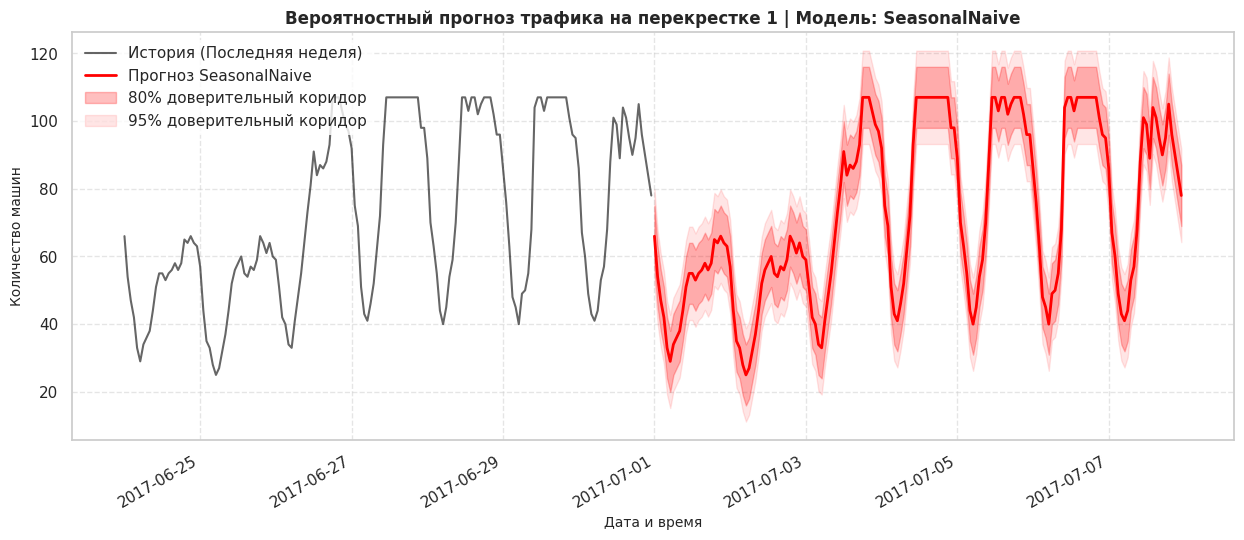

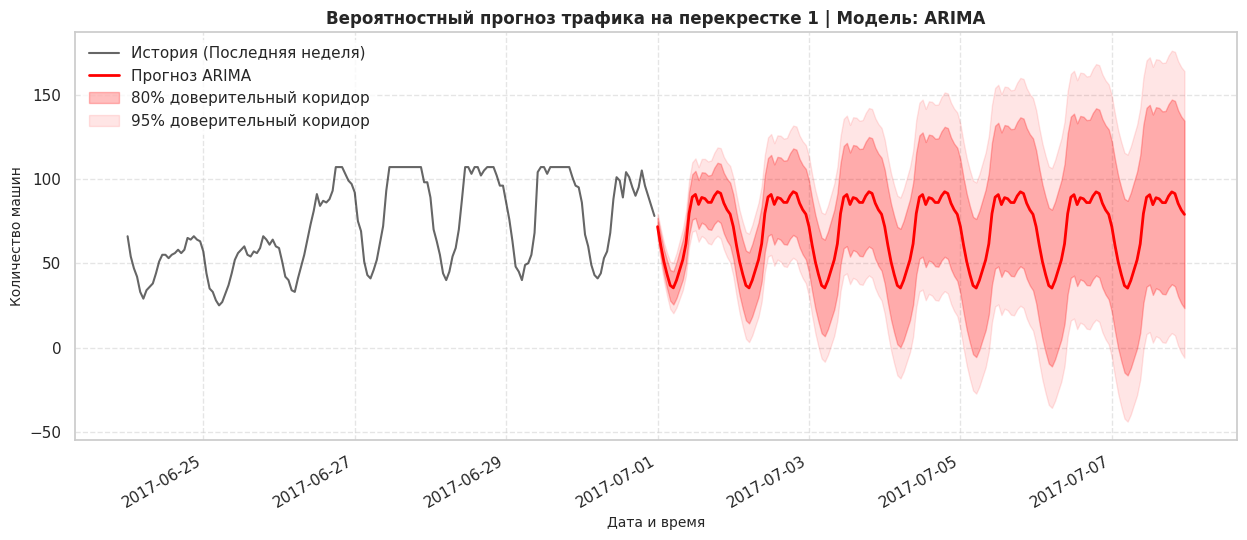

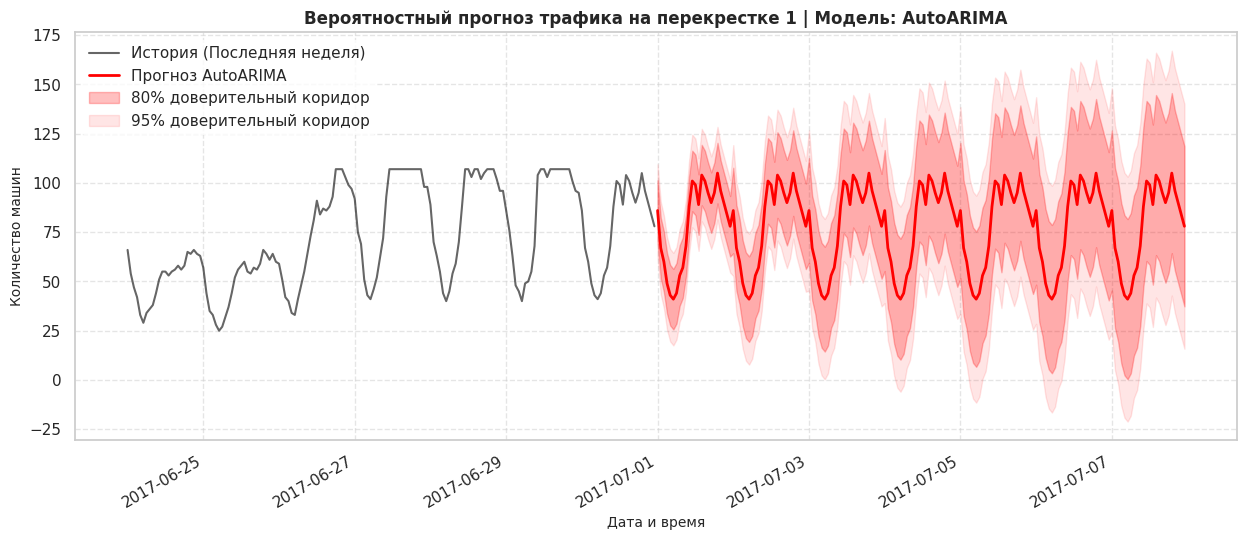

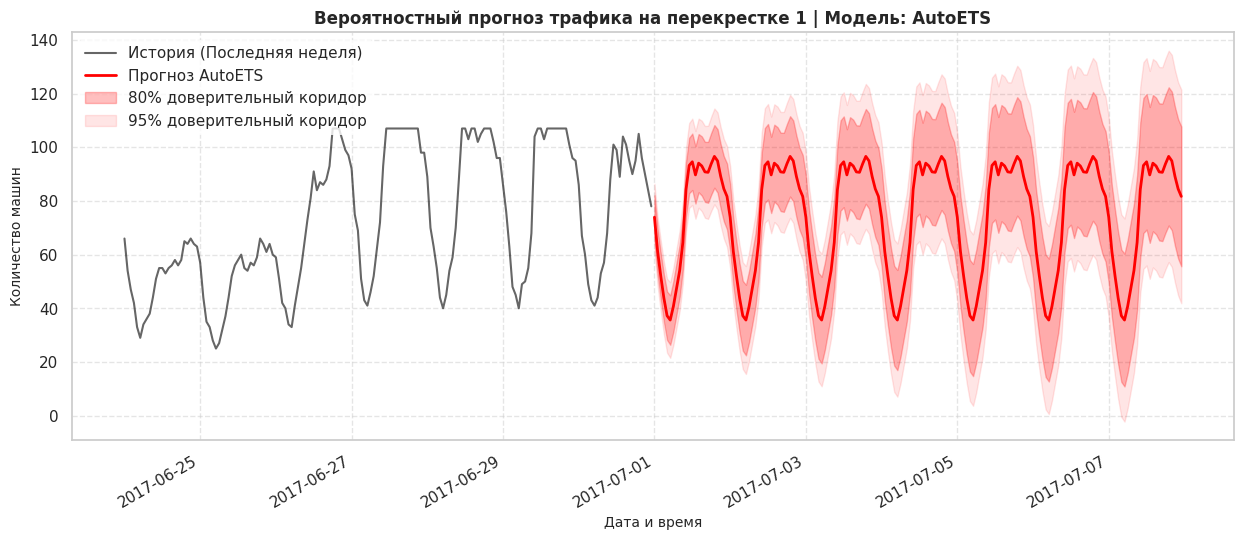

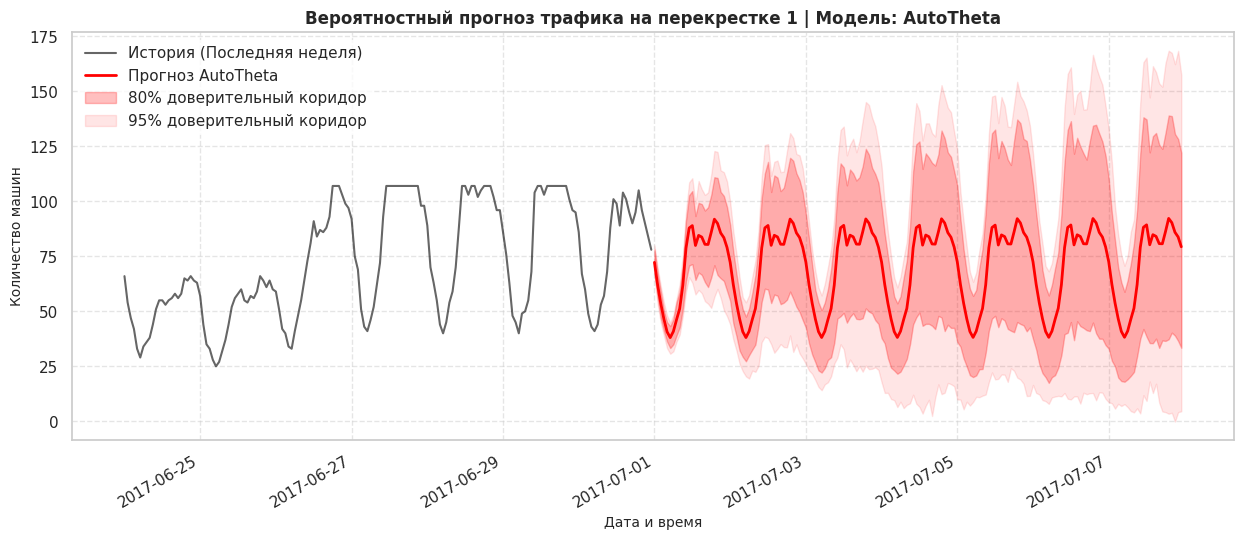

In [6]:
target_uid = 1

# Вырезаем последнюю неделю реальной истории для контекста
history_subset = df[df['unique_id'] == target_uid].tail(168)
# Вырезаем прогноз именно для этого перекрестка
forecast_subset = forecast_df[forecast_df['unique_id'] == target_uid].copy()

# Переводим даты в формат datetime для красивой оси X
history_ds = pd.to_datetime(history_subset['ds'])
forecast_ds = pd.to_datetime(forecast_subset['ds'])

# Строим графики поочередно для каждой модели из нашего пула
for col in model_cols:
    plt.figure(figsize=(15, 6))
    
    # 1. Линия реальной истории (черная)
    plt.plot(history_ds, history_subset['y'], label='История (Последняя неделя)', color='black', alpha=0.6)
    
    # 2. Линия центрального прогноза модели (красная)
    plt.plot(forecast_ds, forecast_subset[col], label=f'Прогноз {col}', color='red', lw=2)
    
    # 3. Заливка 80% доверительного интервала (темнее)
    plt.fill_between(forecast_ds, 
                     forecast_subset[f'{col}-lo-80'], 
                     forecast_subset[f'{col}-hi-80'], 
                     alpha=0.25, color='red', label='80% доверительный коридор')
    
    # 4. Заливка 95% доверительного интервала (светлее)
    plt.fill_between(forecast_ds, 
                     forecast_subset[f'{col}-lo-95'], 
                     forecast_subset[f'{col}-hi-95'], 
                     alpha=0.10, color='red', label='95% доверительный коридор')
    
    # Оформление графика
    plt.title(f'Вероятностный прогноз трафика на перекрестке {target_uid} | Модель: {col}', fontsize=12, fontweight='bold')
    plt.xlabel('Дата и время', fontsize=10)
    plt.ylabel('Количество машин', fontsize=10)
    plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Автоматическое выравнивание дат на оси X
    plt.gcf().autofmt_xdate()
    
    plt.show()

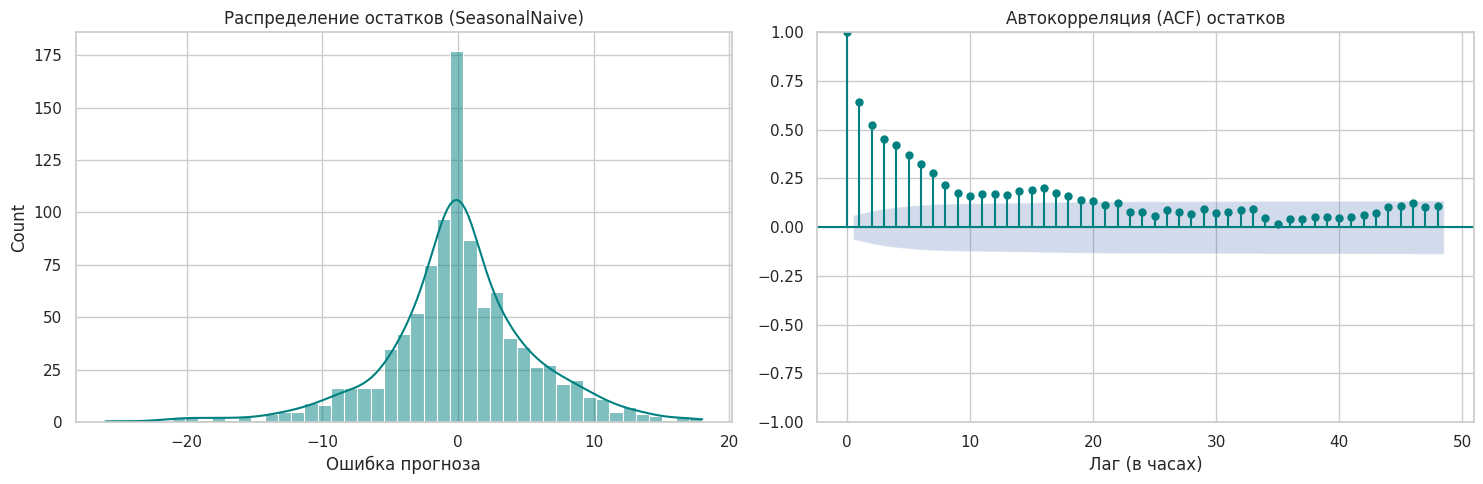

In [7]:
# Считаем остатки (разницу между фактом и прогнозом) на кросс-валидации
residuals = final_cv['y'] - final_cv['SeasonalNaive']

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. Распределение остатков
sns.histplot(residuals, kde=True, ax=ax[0], color='teal')
ax[0].set_title('Распределение остатков (SeasonalNaive)')
ax[0].set_xlabel('Ошибка прогноза')

# 2. Автокорреляция остатков (проверка на белый шум)
plot_acf(residuals.dropna(), lags=48, ax=ax[1], color='teal', vlines_kwargs={"colors": "teal"})
ax[1].set_title('Автокорреляция (ACF) остатков')
ax[1].set_xlabel('Лаг (в часах)')

plt.tight_layout()
plt.show()